# Задача OneMax 
Простая задача оптимизации, которую часто приводят в пример как аналог программы «Hello World» в мире генетических алгоритмов. Задача OneMax состоит в том, чтобы найти двоичную строку заданной длины, для которой сумма составляющих ее цифр максимальна. Например, при решении задачи OneMax длины 5 будут рассматриваться такие кандидаты:
- 10010 (сумма цифр = 2);
- 01110 (сумма цифр = 3);
- 11111 (сумма цифр = 5);


Очевидно, что решением всегда является строка, состоящая из одних единиц. Но генетический алгоритм не обладает таким знанием, поэтому должен слепо искать решение, пользуясь генетическими операторами. Если алгоритм справится с работой, то найдет решение (или приближение к нему) за разумное время.

In [1]:
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from deap import base 
from deap import creator
from deap import tools
from deap import algorithms

In [2]:
sns.set_style("whitegrid")

In [3]:
ONE_MAX_LENGTH = 100    # длина подлежащей оптимизации битовой строки 
POPULATION_SIZE = 200   # количество индивидуумов в популяции
P_CROSSOVER = 0.9       # вероятность скрещивания
P_MUTATION = 0.1        # вероятность мутации индивидуума
MAX_GENERATIONS = 50    # максимальное количество поколений

In [4]:
toolbox = base.Toolbox()

In [5]:
# 1. Регистрируем функцию для формирования гена в хромосоме
toolbox.register(
    "zeroOrOne",                # Название/Псевдоним
    random.randint,             # Функция 
    0, 1                        # Аргументы
)

# 2. Создаем класс FitnessMax с необходимой стратегией оптимизации
creator.create(
    "FitnessMax",               # Название 
    base.Fitness,               # Базовый класс, который расширяем новыми атрибутами
    weights=(1.0,)              # Новые атрибуты
)

# 3. Создаем класс Individual для хранения хромосомы (набор генов).
creator.create(
    "Individual",       
    list,               
    fitness=creator.FitnessMax
)

In [6]:
# 4. Регистрируем оператор individualCreator для создания экземпляра класса Individual заполненный случайными значениями 0 или 1
toolbox.register(
    "individualCreator",        # Название/Псевдоним
    tools.initRepeat,           # Базовый класс
    creator.Individual,         # Тип контейнера в который помещаются созданные объекты
    toolbox.zeroOrOne,          # Функция для генерации объектов
    ONE_MAX_LENGTH              # Константа в качестве количества генерируемых объектов
)

In [7]:
# 5. Регистрируем оператор populationCreator создающий список индивидуумов
toolbox.register(
    "populationCreator",        # Название/Псевдоним
    tools.initRepeat,           # Базовый класс
    list,                       # Тип контейнера
    toolbox.individualCreator   # Функция для генерации объектов в списке
)

In [8]:
# 6. Определим функцию для вычисления приспособленности каждого индивидуума и псевдоним для нее
def oneMaxFitness(individual):
    return sum(individual),     # Вернуть кортеж 

toolbox.register("evaluate", oneMaxFitness)

## Baseline

In [9]:
# В DEAP генетические операторы обычно создаются как псевдонимы существующих функций 
# из модуля src с конкретными значениями аргументов
toolbox.register(
    "select",                       # Отбор
    tools.selTournament,            # Турнир 
    tournsize=3                     # Размер турнира
)

toolbox.register(
    "mate",                         # Скрещивание
    tools.cxOnePoint                # Одноточечное
)

toolbox.register(
    "mutate",                       # Мутация 
    tools.mutFlipBit,               # Инвертирование битом
    indpb=1.0/ONE_MAX_LENGTH        # Вероятность инвертирования бита (гена в хромосоме)
)

In [10]:
# Реализация генетического алгоритма
def main():
    random.seed(42)
    
    # Начальная популяция.
    population = toolbox.populationCreator(n=POPULATION_SIZE)
    generationCounter = 0
    
    # Вычисляем приспособленность каждого индивидуума в начальной популяции используя 
    # созданный ранее псевдоним функции oneMaxFitness()
    fitnessValues = list(map(toolbox.evaluate, population))
    
    # Сопоставим каждому индивидууму его приспособленность
    for individual, fitnessValue in zip(population, fitnessValues):
        individual.fitness.values = fitnessValue
        
    # Извлекаем первое значение из каждого кортежа приспособленности для сбора статистики
    fitnessValues = [individual.fitness.values[0] for individual in population]
    
    # Для хранения статистик
    maxFitnessValues, meanFitnessValues = [], []
    
    # Главный цикл генетического алгоритма
    while max(fitnessValues) < ONE_MAX_LENGTH and generationCounter < MAX_GENERATIONS:
        generationCounter += 1
        
        # Генетический оператор – отбор
        offspring = toolbox.select(population, len(population))
        offspring = list(map(toolbox.clone, offspring))
        
        # Генетический оператор – скрещивание
        # Через срезы выберем четные и нечетные элементы для создания пары
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < P_CROSSOVER:
                toolbox.mate(child1, child2)
                del child1
                del child2
                
        # Генетический оператор – мутация
        # Если индивидуум подвергся мутации, то необходимо удалить значение его приспособленности
        # так как оно могло быть перенесено из предыдущего поколения
        for mutant in offspring:
            if random.random() < P_MUTATION:
                toolbox.mutate(mutant)
                del mutant.fitness.values
        
        # Пересчитываем приспособленность у индивидуумов после скрещивания/мутации
        # Это будут все индивидуумы с пустым значенеим приспособленности
        freshIndividuals = [ind for ind in offspring if not ind.fitness.valid]
        freshFitnessValues = list(map(toolbox.evaluate, freshIndividuals))
        for individual, fitnessValue in zip(freshIndividuals, freshFitnessValues):
            individual.fitness.values = fitnessValue
            
        # Заменяем старую популяцию новой
        population[:] = offspring
        
        # Собираем статистику
        fitnessValues = [ind.fitness.values[0] for ind in population]
        maxFintess = max(fitnessValues)
        meanFitness = sum(fitnessValues) / len(population)
        maxFitnessValues.append(maxFintess)
        meanFitnessValues.append(meanFitness)
    
    # Визуализируем динамику
    plt.figure(figsize=(15, 5))
    generations = range(1, len(maxFitnessValues) + 1)
    sns.lineplot(x=generations, y=maxFitnessValues, color='red', label='Максимальное')
    sns.lineplot(x=generations, y=meanFitnessValues, color='green', label='Среднее')
    
    plt.xlabel('Поколения')
    plt.ylabel('Максимальное / Среднее')
    plt.title('Динамика приспособленности в поколениях')
    
    plt.show()

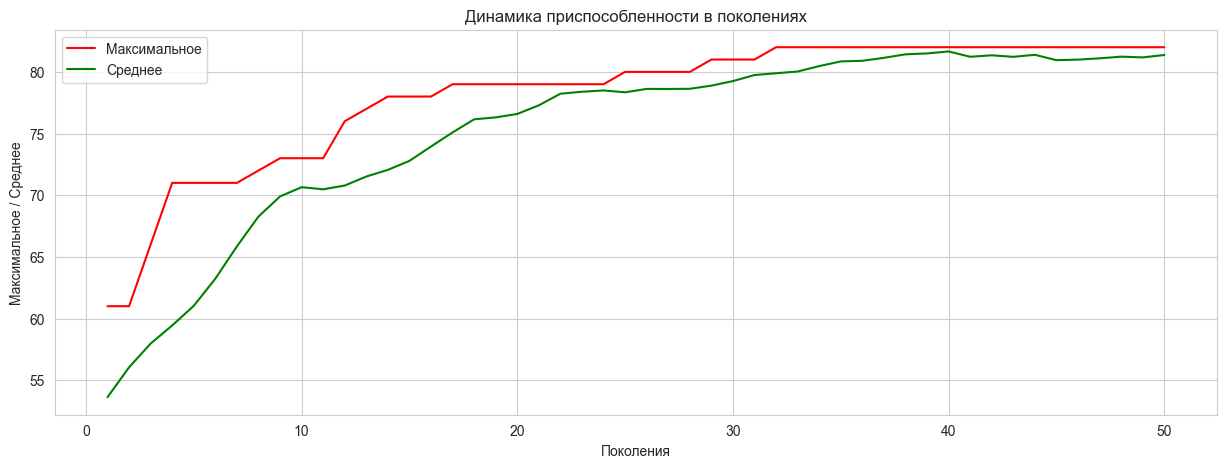

In [11]:
main()

## DEAP. Встроенные алгоритмы

In [18]:
# Реализация генетического алгоритма
def main():
    random.seed(42)
    
    # Начальная популяция.
    population = toolbox.populationCreator(n=POPULATION_SIZE)
    
    # Создаем класс для сбора статистики задав функцию, применяемую к данным, для которых вычисляется статистика
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("max", np.max)
    stats.register("avg", np.mean)
    
    # Определяем зал славы 
    hof = tools.HallOfFame(10)
    
    # Главный цикл генетического алгоритма
    # Метод algorithms.eaSimple предполагает, что в toolbox уже зарегистрированы операторы: evaluate, select, mate, mutate
    population, logbook = algorithms.eaSimple(
        population=population, 
        toolbox=toolbox, 
        cxpb=P_CROSSOVER, 
        mutpb=P_MUTATION, 
        ngen=MAX_GENERATIONS, 
        stats=stats,
        halloffame=hof, 
        verbose=True
    )
    
    # Выводим зал славы
    print("Индивидуумы попавшие в щал славы: ", *hof.items, sep="\n")
    print("Самый лучший индивидуум: ", hof.items[0])

    
    # Извлекаем статистику 
    maxFitnessValues, meanFitnessValues = logbook.select("max", "avg")
    
    # Визуализируем динамику
    plt.figure(figsize=(15, 5))
    generations = range(1, len(maxFitnessValues) + 1)
    sns.lineplot(x=generations, y=maxFitnessValues, color='red', label='Максимальное')
    sns.lineplot(x=generations, y=meanFitnessValues, color='green', label='Среднее')
    
    plt.xlabel('Поколения')
    plt.ylabel('Максимальное / Среднее')
    plt.title('Динамика приспособленности в поколениях')
    
    plt.show()

gen	nevals	max	avg   
0  	200   	61 	49.695
1  	193   	65 	53.575
2  	179   	66 	56.855
3  	187   	69 	59.42 
4  	184   	70 	62.03 
5  	188   	75 	64.715
6  	176   	75 	67.515
7  	184   	77 	70.215
8  	180   	81 	72.475
9  	174   	82 	74.79 
10 	172   	85 	76.685
11 	177   	85 	78.46 
12 	178   	87 	80.265
13 	178   	87 	81.8  
14 	184   	87 	83.15 
15 	181   	89 	84.4  
16 	185   	89 	85.59 
17 	174   	90 	86.755
18 	186   	91 	87.715
19 	184   	92 	88.495
20 	178   	92 	89.275
21 	176   	93 	90.04 
22 	185   	94 	90.865
23 	180   	94 	91.645
24 	177   	95 	92.69 
25 	191   	95 	93.325
26 	169   	95 	93.935
27 	184   	96 	94.39 
28 	184   	96 	94.84 
29 	179   	96 	95.07 
30 	183   	97 	95.325
31 	180   	97 	95.69 
32 	189   	97 	95.93 
33 	177   	97 	96.085
34 	188   	98 	96.325
35 	169   	98 	96.835
36 	182   	98 	97.18 
37 	183   	99 	97.655
38 	182   	99 	97.91 
39 	192   	99 	98.04 
40 	173   	100	98.29 
41 	182   	100	98.55 
42 	176   	100	98.915
43 	188   	100	99.195
44 	192   

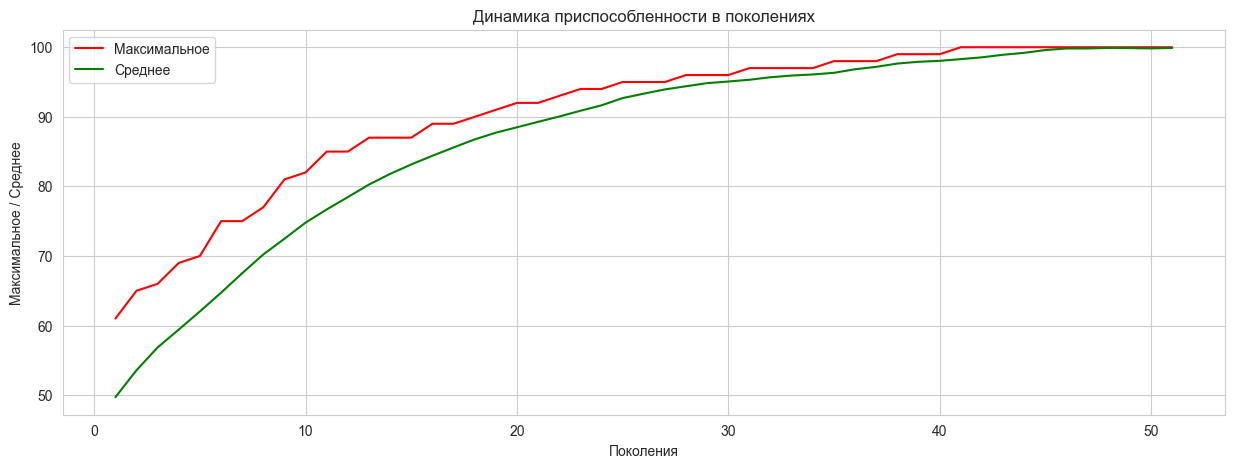

In [19]:
main()